# 5. Frequency Domain

## Table of Contents
1. [Libraries](#libraries)
2. [Fast Fourier Transform (FFT)](#fft)
3. [Low Pass Filter](#low)
4. [High Pass Filter](#high)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt,exp

## Fast Fourier Transform (FFT) <a class="anchor" id="fft" ></a>

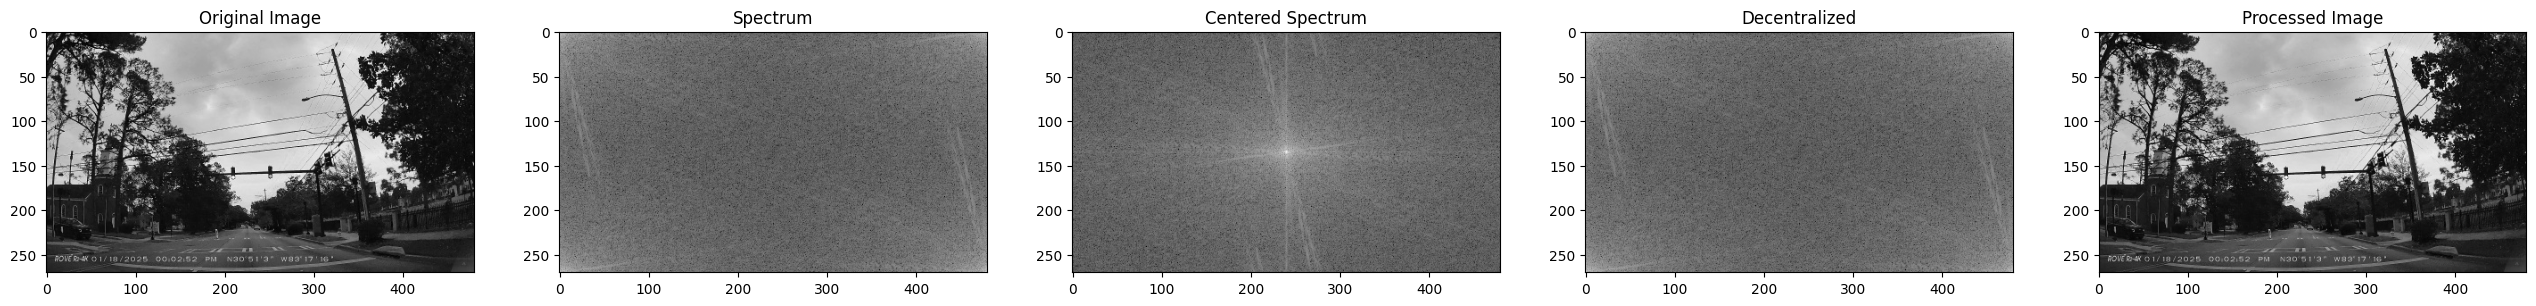

In [2]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)
plt.subplot(151), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(152), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(153), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

inv_center = np.fft.ifftshift(center)
plt.subplot(154), plt.imshow(np.log(1+np.abs(inv_center)), "gray"), plt.title("Decentralized")

processed_img = np.fft.ifft2(inv_center)
plt.subplot(155), plt.imshow(np.abs(processed_img), "gray"), plt.title("Processed Image")

plt.show()

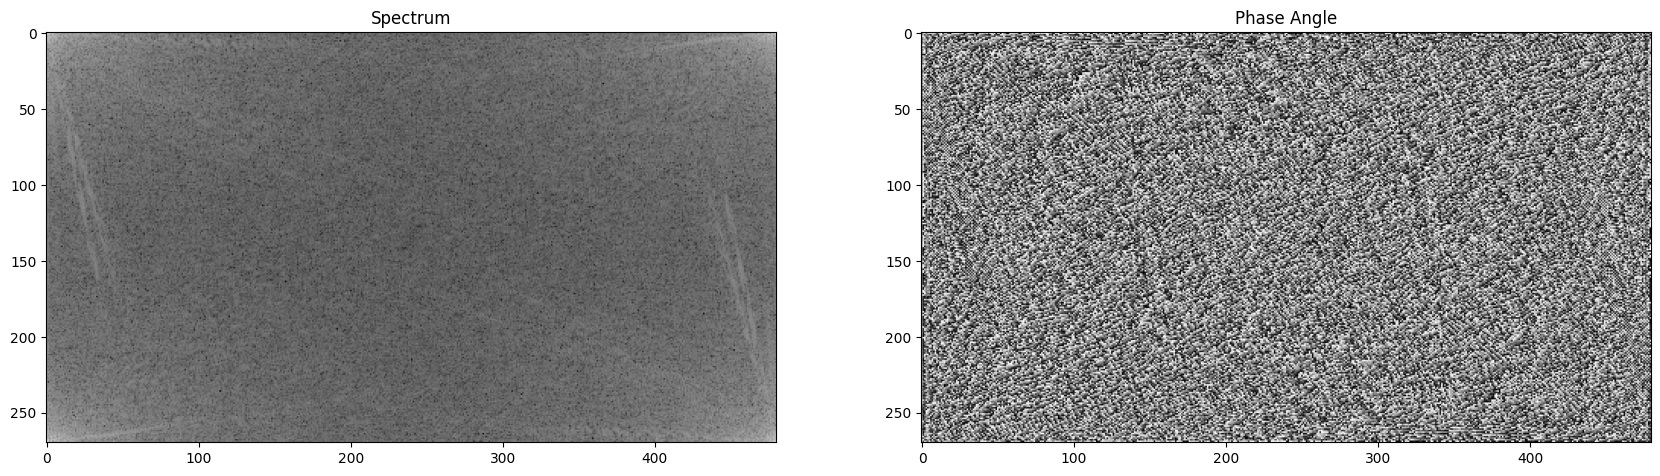

In [3]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)

original = np.fft.fft2(img)
plt.subplot(131), plt.imshow(np.log(np.abs(original)), "gray"), plt.title("Spectrum")

plt.subplot(132), plt.imshow(np.angle(original), "gray"), plt.title("Phase Angle")
plt.show()

In [4]:
def distance(point1,point2):
    return sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

def idealFilterLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 1
    return base

def idealFilterHP(D0,imgShape):
    base = np.ones(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 0
    return base

def butterworthLP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def butterworthHP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1-1/(1+(distance((y,x),center)/D0)**(2*n))
    return base

def gaussianLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

def gaussianHP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1 - exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

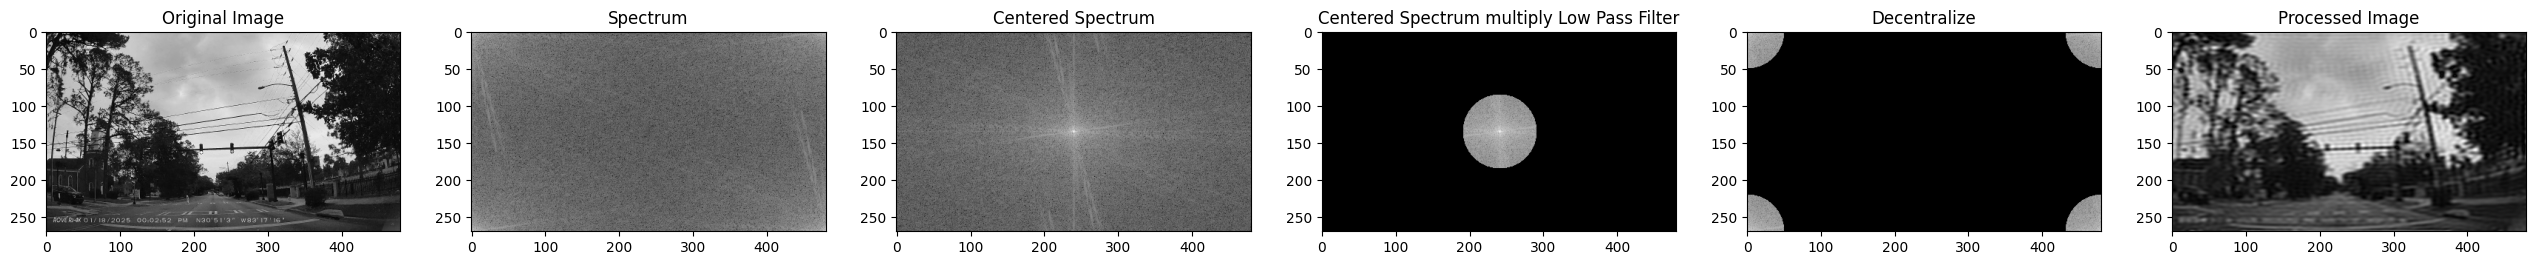

In [5]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

img = cv2.imread("data/image.jpg", 0)
plt.subplot(161), plt.imshow(img, "gray"), plt.title("Original Image")

original = np.fft.fft2(img)
plt.subplot(162), plt.imshow(np.log(1+np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(163), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Centered Spectrum")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(164), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(165), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(166), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## Low Pass Filter <a class="anchor" id="low" ></a>

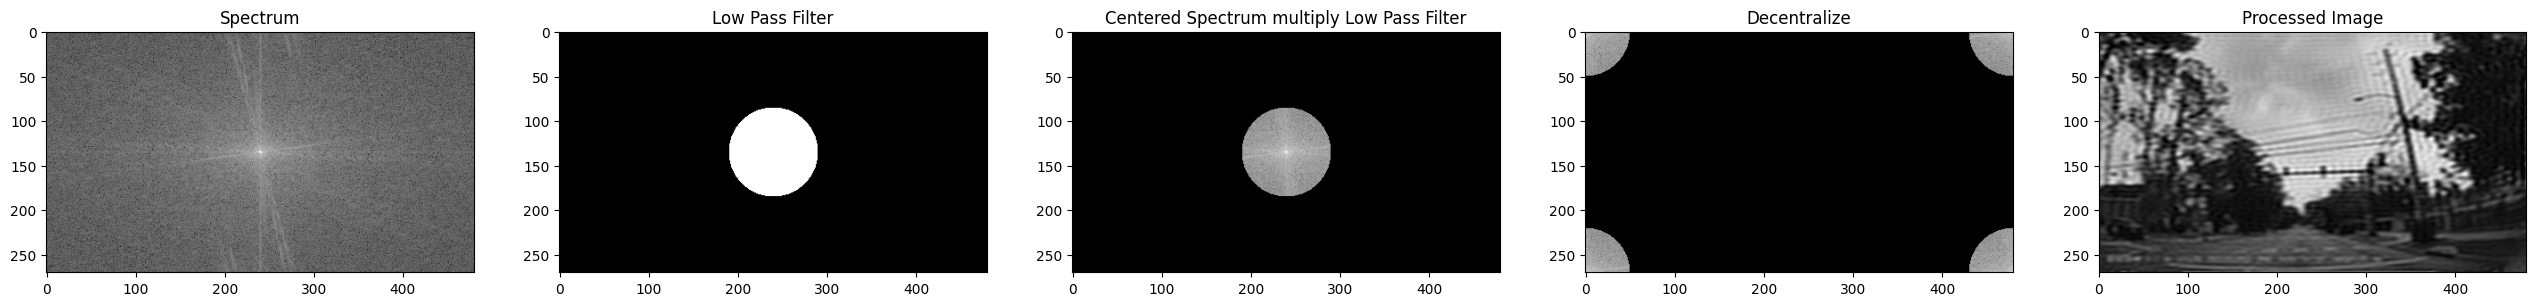

In [6]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

LowPass = idealFilterLP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(LowPass), "gray"), plt.title("Low Pass Filter")

LowPassCenter = center * idealFilterLP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(LowPassCenter)), "gray"), plt.title("Centered Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(155), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

## High Pass Filter <a class="anchor" id="high" ></a>

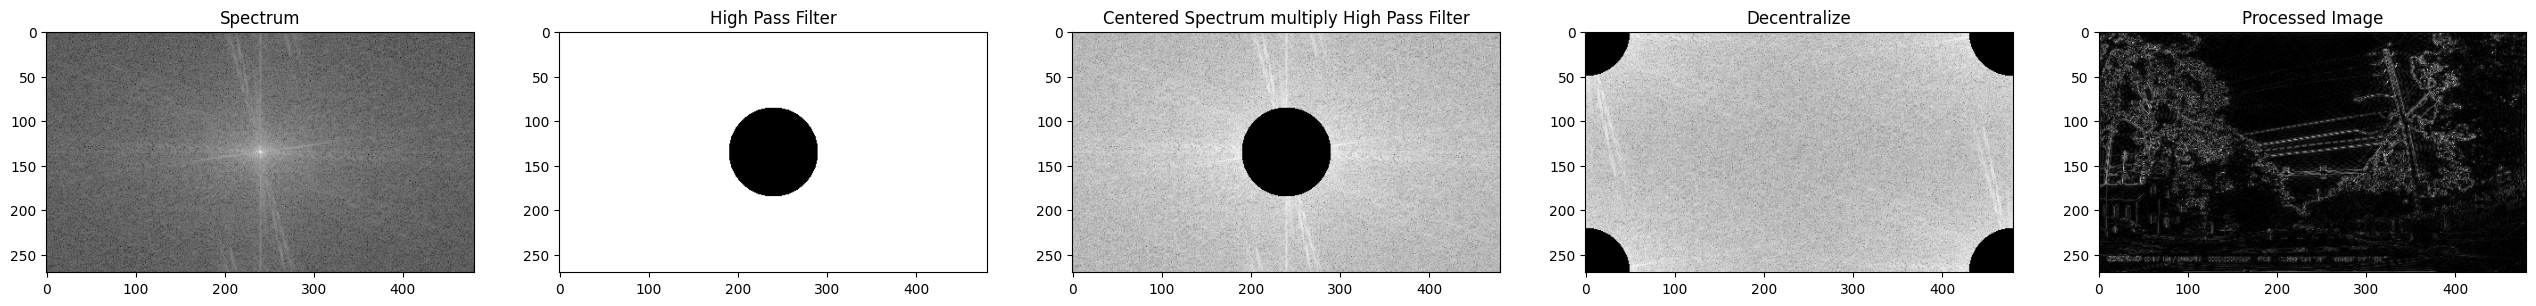

In [7]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(151), plt.imshow(np.log(1+np.abs(center)), "gray"), plt.title("Spectrum")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(152), plt.imshow(np.abs(HighPass), "gray"), plt.title("High Pass Filter")

HighPassCenter = center * idealFilterHP(50,img.shape)
plt.subplot(153), plt.imshow(np.log(1+np.abs(HighPassCenter)), "gray"), plt.title("Centered Spectrum multiply High Pass Filter")

HighPass = np.fft.ifftshift(HighPassCenter)
plt.subplot(154), plt.imshow(np.log(1+np.abs(HighPass)), "gray"), plt.title("Decentralize")

inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(155), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Processed Image")

plt.show()

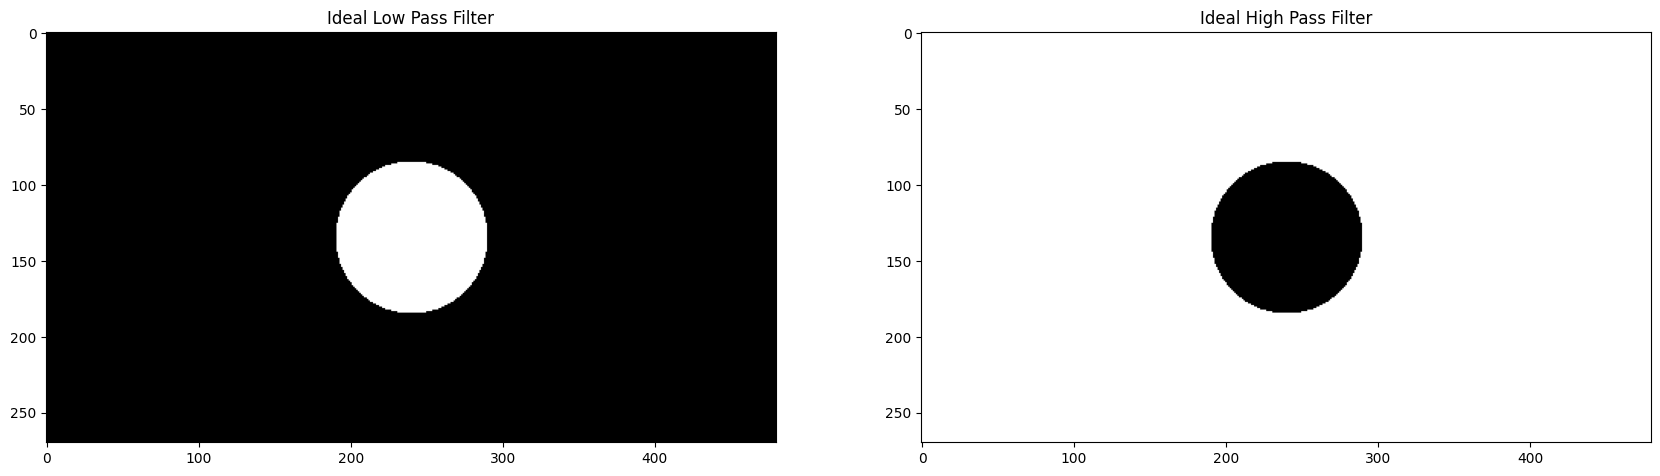

In [8]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Ideal Low Pass Filter")

HighPass = idealFilterHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Ideal High Pass Filter")

plt.show()

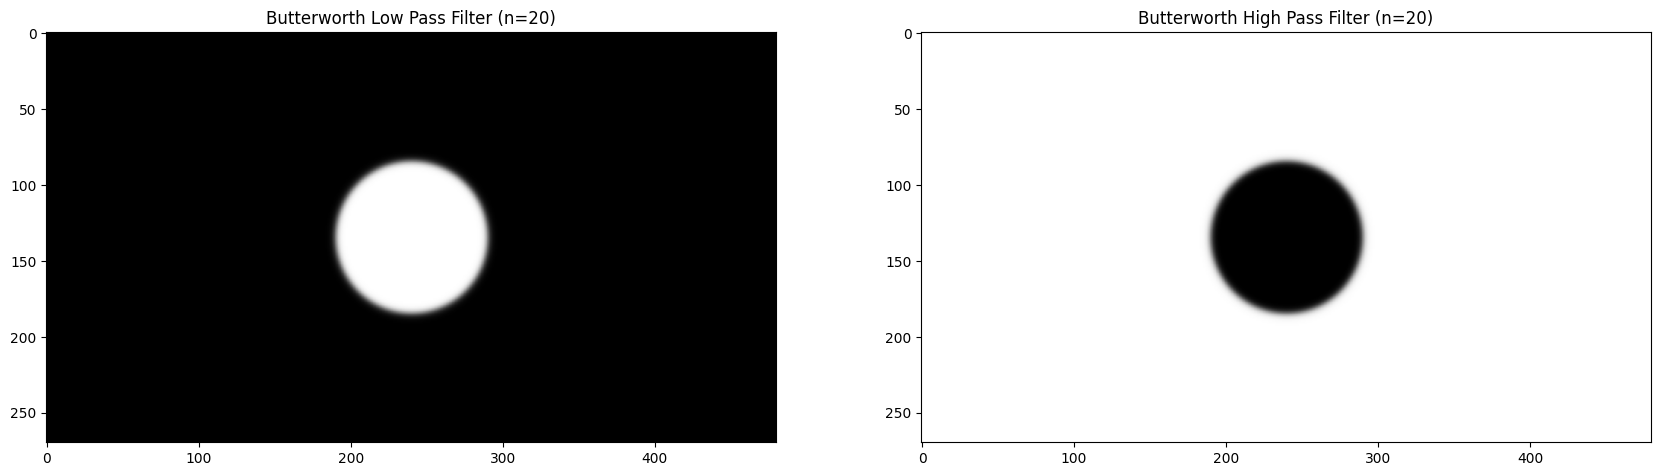

In [9]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,20)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=20)")

HighPass = butterworthHP(50,img.shape,20)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=20)")

plt.show()

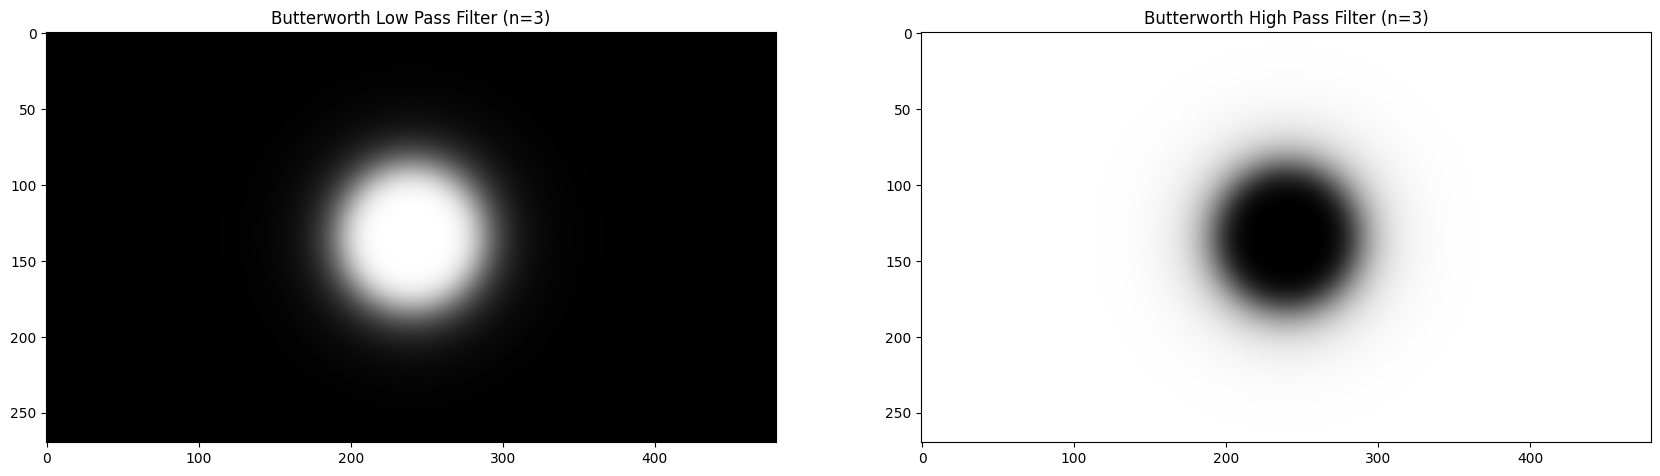

In [10]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = butterworthLP(50,img.shape,3)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Butterworth Low Pass Filter (n=3)")

HighPass = butterworthHP(50,img.shape,3)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Butterworth High Pass Filter (n=3)")

plt.show()

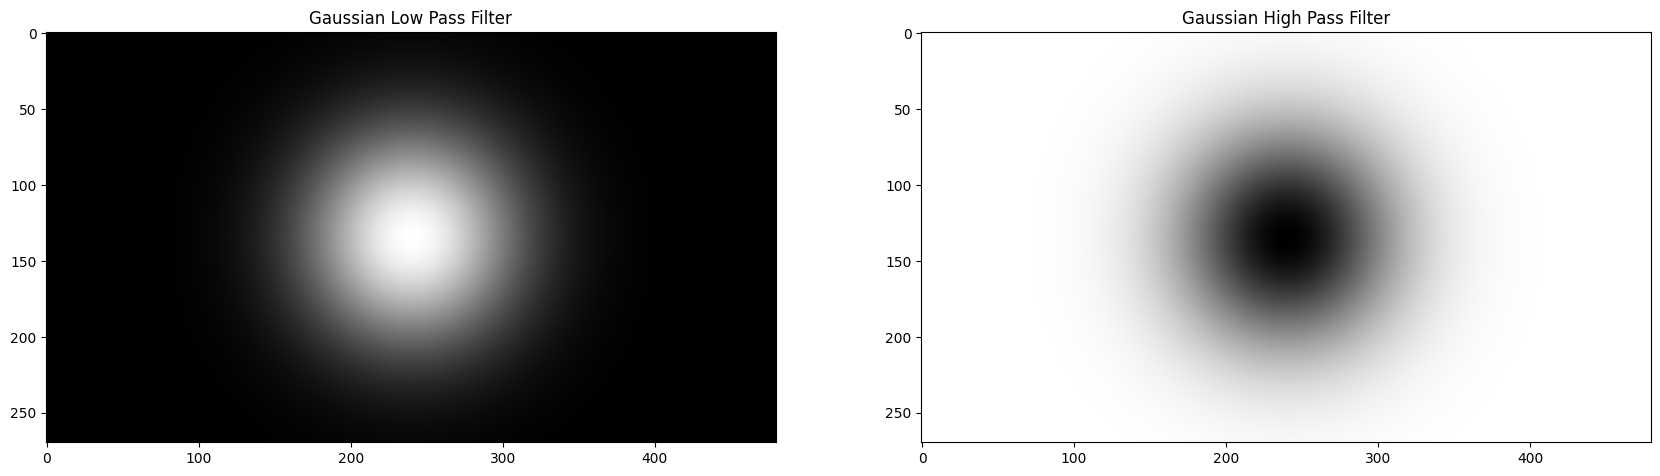

In [11]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = gaussianLP(50,img.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Gaussian Low Pass Filter")

HighPass = gaussianHP(50,img.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

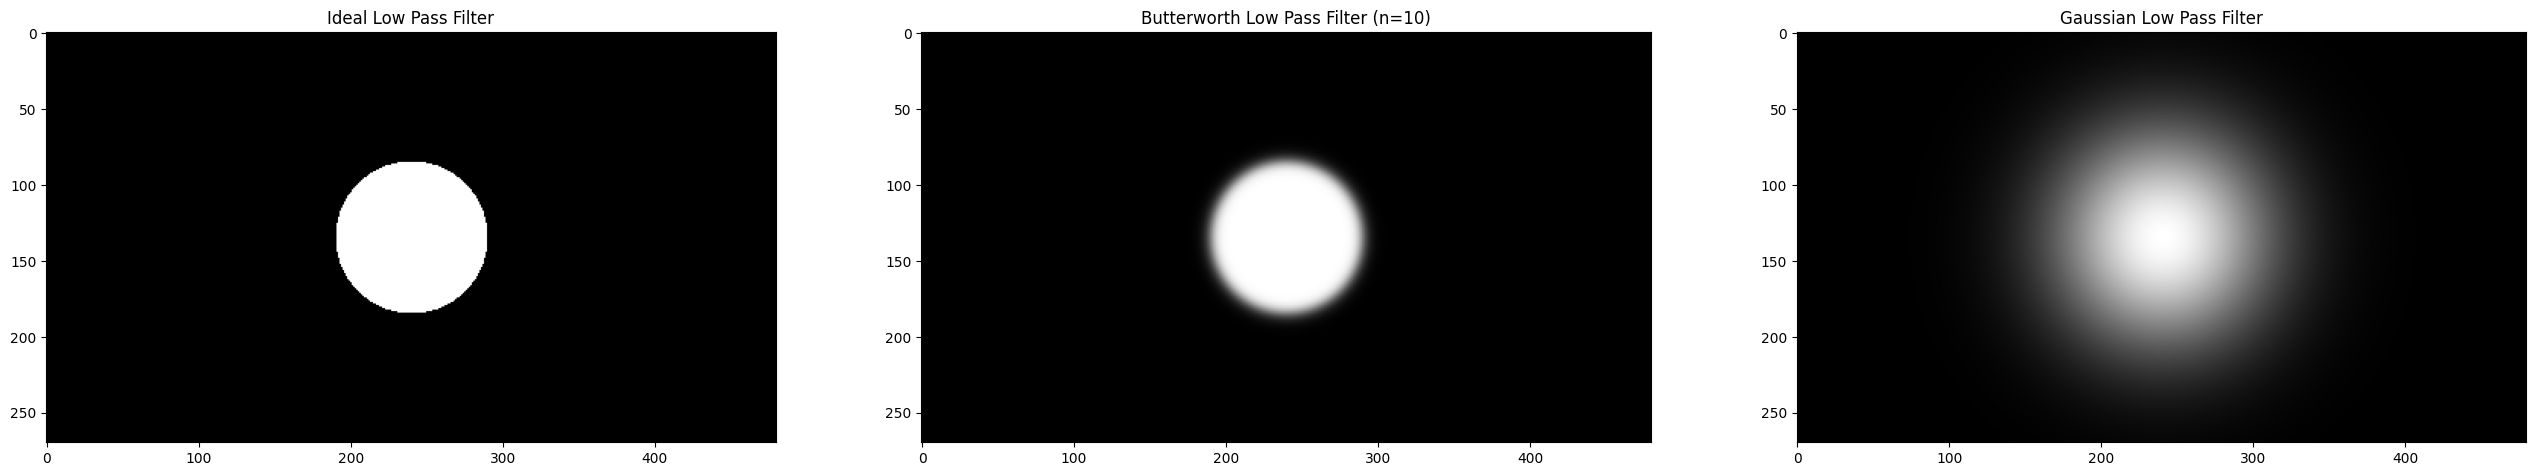

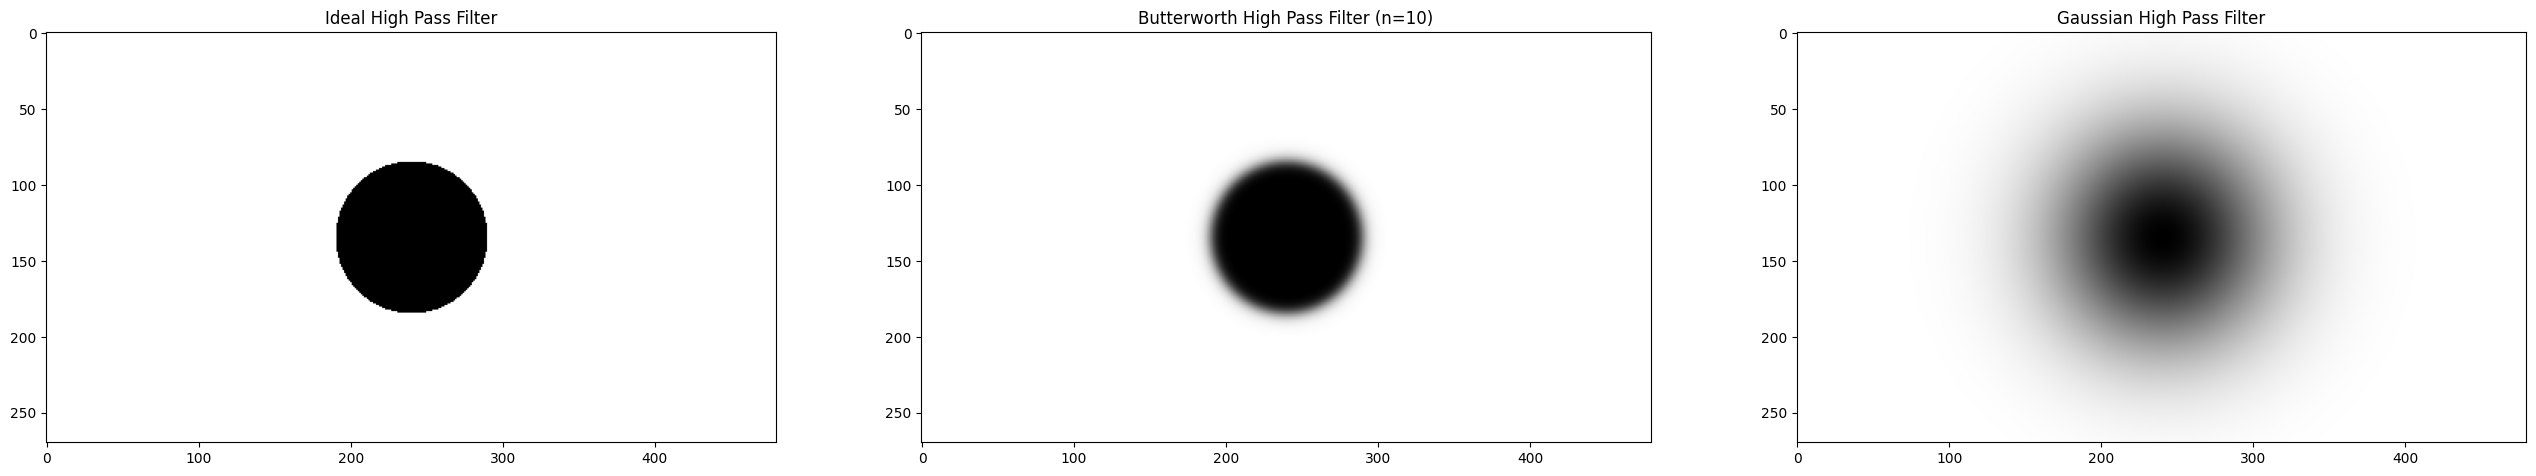

In [12]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

IdealLP = idealFilterLP(50,img.shape)
plt.subplot(131), plt.imshow(IdealLP, "gray"), plt.title("Ideal Low Pass Filter")

ButterLP = butterworthLP(50,img.shape,10)
plt.subplot(132), plt.imshow(ButterLP, "gray"), plt.title("Butterworth Low Pass Filter (n=10)")

GaussianLP = gaussianLP(50,img.shape)
plt.subplot(133), plt.imshow(GaussianLP, "gray"), plt.title("Gaussian Low Pass Filter")

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)
IdealHP = idealFilterHP(50,img.shape)
plt.subplot(231), plt.imshow(IdealHP, "gray"), plt.title("Ideal High Pass Filter")

ButterHP = butterworthHP(50,img.shape,10)
plt.subplot(232), plt.imshow(ButterHP, "gray"), plt.title("Butterworth High Pass Filter (n=10)")

GaussianHP = gaussianHP(50,img.shape)
plt.subplot(233), plt.imshow(GaussianHP, "gray"), plt.title("Gaussian High Pass Filter")

plt.show()

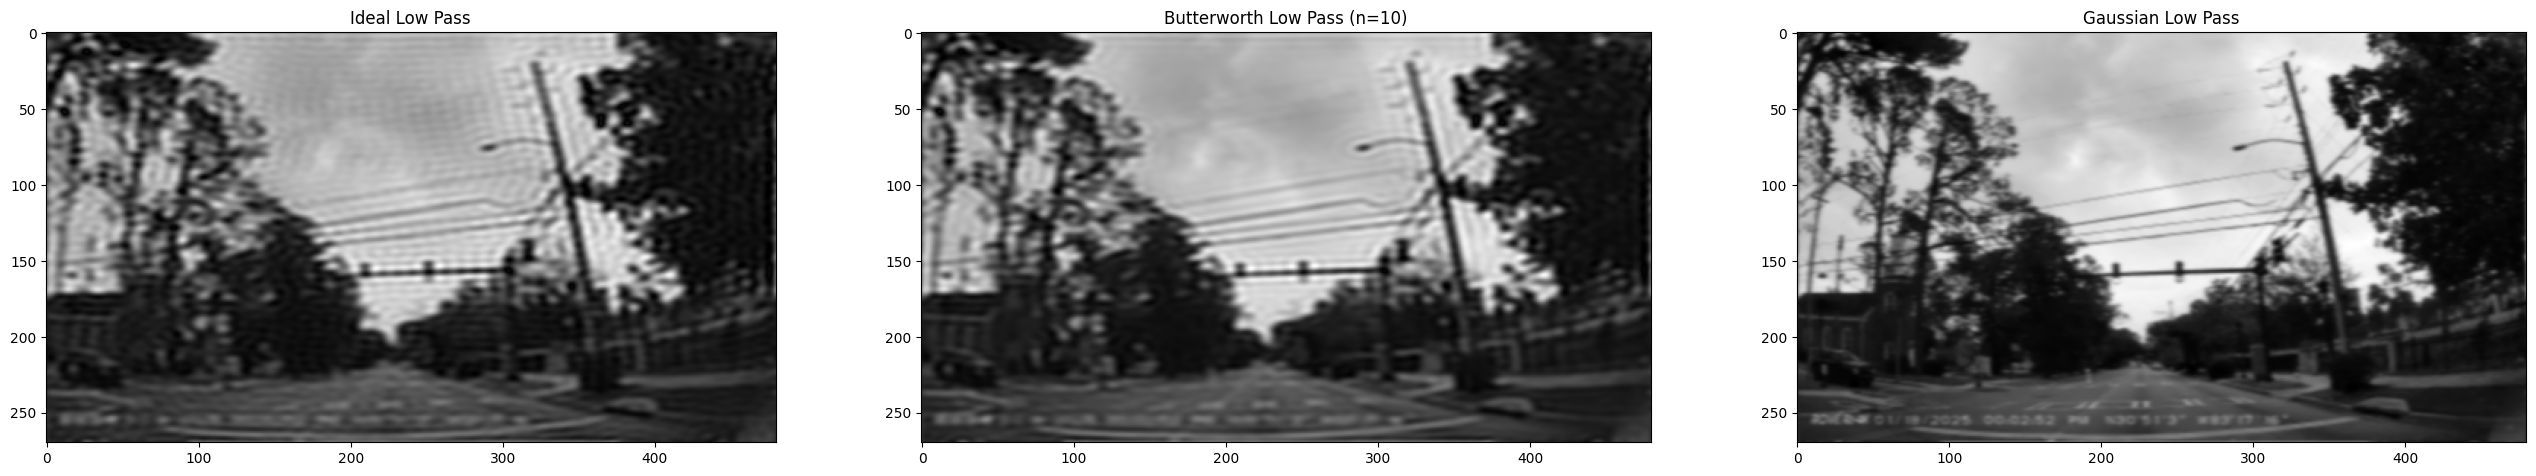

In [13]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPassCenter = center * idealFilterLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(131), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Ideal Low Pass")

LowPassCenter = center * butterworthLP(50,img.shape,10)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (n=10)")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(133), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

plt.show()

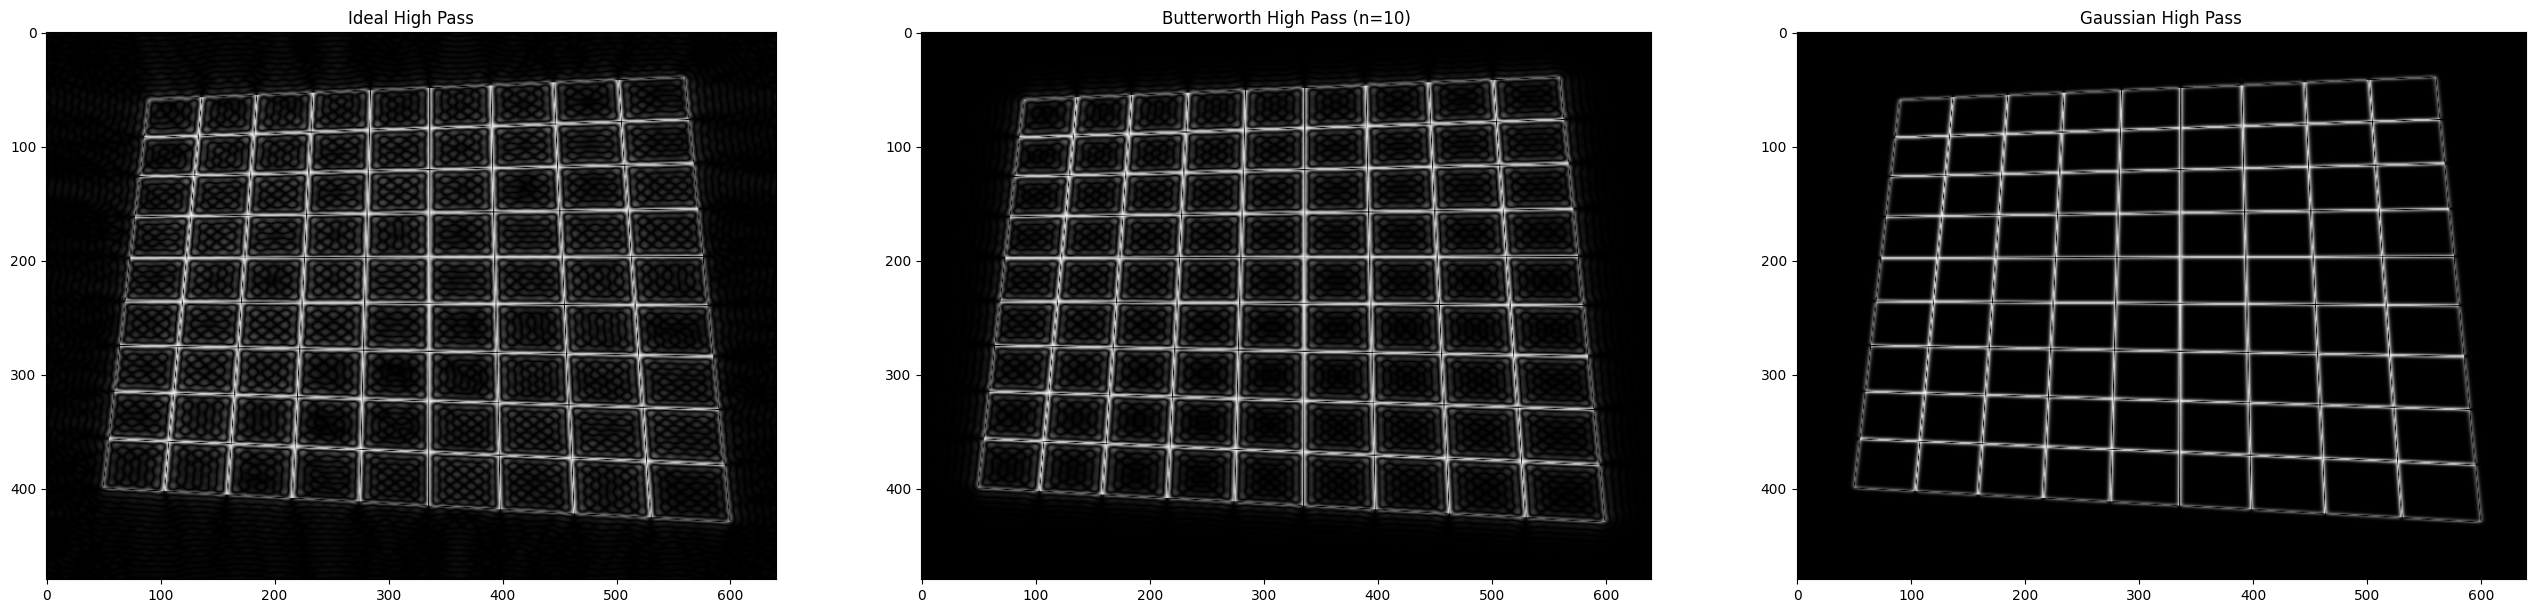

In [14]:
img = cv2.imread("left01.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

HighPassCenter = center * idealFilterHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(131), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Ideal High Pass")

HighPassCenter = center * butterworthHP(50,img.shape,10)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(132), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (n=10)")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

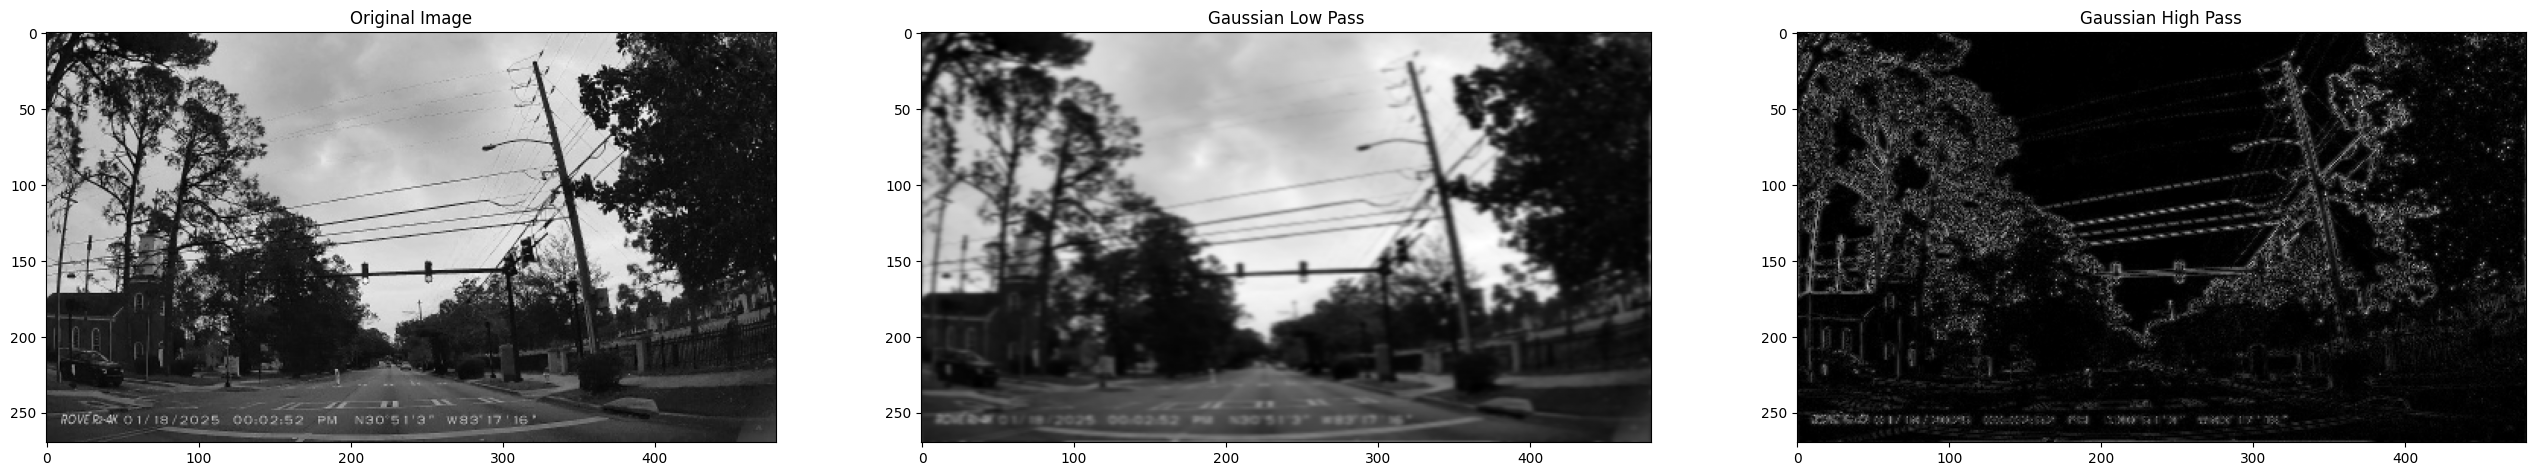

In [15]:
img = cv2.imread("data/image.jpg", 0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

plt.subplot(131), plt.imshow(img, "gray"), plt.title("Original Image")

LowPassCenter = center * gaussianLP(50,img.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(132), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Gaussian Low Pass")

HighPassCenter = center * gaussianHP(50,img.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(133), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Gaussian High Pass")

plt.show()

# Ejercicios de la actividad

En el notebook base se implementan los tres filtros básicos con bucles sobre cada píxel. Aquí se reescriben de forma **vectorizada** (mucho más rápida) y se usan en dos aplicaciones, cada una medida contra una imagen de referencia limpia:

1. [Ejercicio a) Filtro pasa bajas: reducción de ruido en una radiografía](#a)
2. [Ejercicio b) Filtro pasa altas: recuperar nitidez (énfasis de alta frecuencia)](#b)
3. [Conclusión](#conclusion)

Los tres filtros, con $D(u,v)$ la distancia al centro del espectro y $D_0$ la frecuencia de corte:

| Filtro | Pasa bajas $H(u,v)$ | Pasa altas |
|---|---|---|
| Ideal | $1$ si $D \le D_0$, $0$ si no | $1 - H_{LP}$ |
| Butterworth (orden $n$) | $1 / \left(1 + (D/D_0)^{2n}\right)$ | $1 - H_{LP}$ |
| Gaussiano | $e^{-D^2/(2D_0^2)}$ | $1 - H_{LP}$ |

El filtro ideal corta de golpe y produce **oscilaciones (efecto de anillo o *ringing*)** en la imagen filtrada; el Butterworth transiciona más suave (menos anillo cuanto menor $n$) y el gaussiano no produce anillo.

In [16]:
import numpy as np, cv2, matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
plt.rcParams.update({"font.size": 9})

def malla_distancia(forma):
    filas, cols = forma
    v, u = np.meshgrid(np.arange(cols) - cols / 2, np.arange(filas) - filas / 2)
    return np.hypot(u, v)

def pasa_bajas(forma, D0, tipo, n=2):
    D = malla_distancia(forma)
    if tipo == "ideal": return (D < D0).astype(float)      # igual que idealFilterLP del notebook base (distancia estricta)
    if tipo == "butterworth": return 1 / (1 + (D / D0) ** (2 * n))
    if tipo == "gaussiano": return np.exp(-(D ** 2) / (2 * D0 ** 2))
    raise ValueError(tipo)

def pasa_altas(forma, D0, tipo, n=2): return 1 - pasa_bajas(forma, D0, tipo, n)

def filtrar(img, H):
    F = np.fft.fftshift(np.fft.fft2(img.astype(float)))
    return np.real(np.fft.ifft2(np.fft.ifftshift(F * H)))

def espectro(img): return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(img.astype(float)))))

# Comprobación de que la versión vectorizada coincide con la del notebook base (filtro ideal, D0=50)
base_lp = idealFilterLP(50, img.shape)
print("Máxima diferencia con idealFilterLP del notebook base:", np.abs(base_lp - pasa_bajas(img.shape, 50, "ideal")).max())

Máxima diferencia con idealFilterLP del notebook base: 0.0


<a id="a"></a>
## Ejercicio a) Filtro pasa bajas: reducción de ruido en una radiografía

**Investigación.** El ruido (del detector, de la cuantización o del bajo número de fotones) es un fenómeno de **alta frecuencia**: cambia de un píxel al siguiente. Los bordes y detalles también son de alta frecuencia, pero la energía de una imagen natural se concentra en las bajas frecuencias (espectro con un pico central que decae).
Un filtro pasa bajas elimina las componentes por encima de $D_0$ y con ello atenúa el ruido, a costa de suavizar los bordes (Gonzalez & Woods, 2018, cap. 4). En radiología se usa para reducir el ruido cuántico de imágenes de baja dosis antes de segmentar o medir.

**Demo.** A una radiografía de tórax (CC0) se le agrega ruido gaussiano (σ = 25 niveles), y se prueba cada filtro con distintas frecuencias de corte, midiendo **PSNR** y **SSIM** frente a la radiografía original sin ruido.

In [17]:
rx = cv2.imread("data/radiografia.png", 0).astype(float)
rng = np.random.default_rng(3)
ruidosa = np.clip(rx + rng.normal(0, 25, rx.shape), 0, 255)

cortes = [15, 30, 50, 80, 120]
tipos = ["ideal", "butterworth", "gaussiano"]
tabla = {}
for t in tipos:
    for D0 in cortes:
        s = np.clip(filtrar(ruidosa, pasa_bajas(rx.shape, D0, t)), 0, 255)
        tabla[(t, D0)] = (psnr(rx, s, data_range=255), ssim(rx, s, data_range=255), s)

print(f"Imagen con ruido: PSNR = {psnr(rx, ruidosa, data_range=255):.2f} dB, SSIM = {ssim(rx, ruidosa, data_range=255):.3f}\n")
print(f"{'filtro':13s} " + " ".join(f"D0={D:<4d}" for D in cortes) + "   (PSNR en dB / SSIM)")
for t in tipos:
    print(f"{t:13s} " + " ".join(f"{tabla[(t, D)][0]:5.2f}/{tabla[(t, D)][1]:.2f}" for D in cortes))
mejor = {t: max(cortes, key=lambda D: tabla[(t, D)][0]) for t in tipos}
print("\nMejor D0 por filtro:", mejor)

Imagen con ruido: PSNR = 20.26 dB, SSIM = 0.160

filtro        D0=15   D0=30   D0=50   D0=80   D0=120    (PSNR en dB / SSIM)
ideal         27.54/0.80 30.04/0.83 30.68/0.79 29.35/0.65 26.72/0.46
butterworth   28.26/0.83 30.85/0.87 31.61/0.84 30.36/0.70 27.77/0.52
gaussiano     28.70/0.84 31.15/0.87 31.52/0.81 29.70/0.64 26.87/0.45

Mejor D0 por filtro: {'ideal': 50, 'butterworth': 50, 'gaussiano': 50}


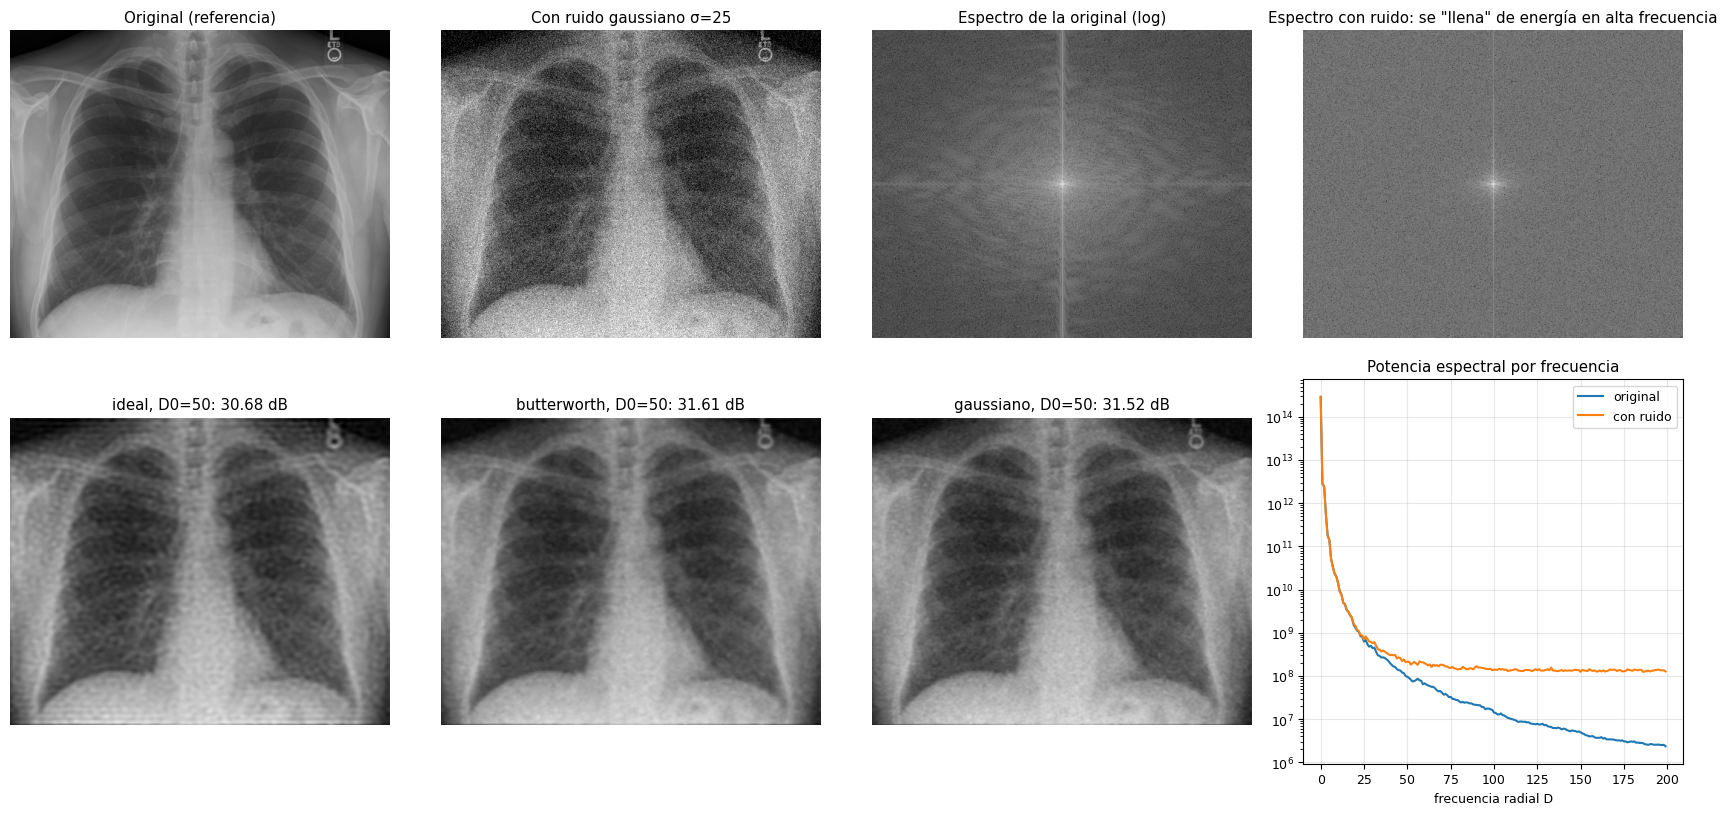

filtro         sobreimpulso  subimpulso   (respecto al salto de 255 niveles)
ideal                  9.0%        9.0%
butterworth            3.3%        3.3%
gaussiano              0.0%        0.0%


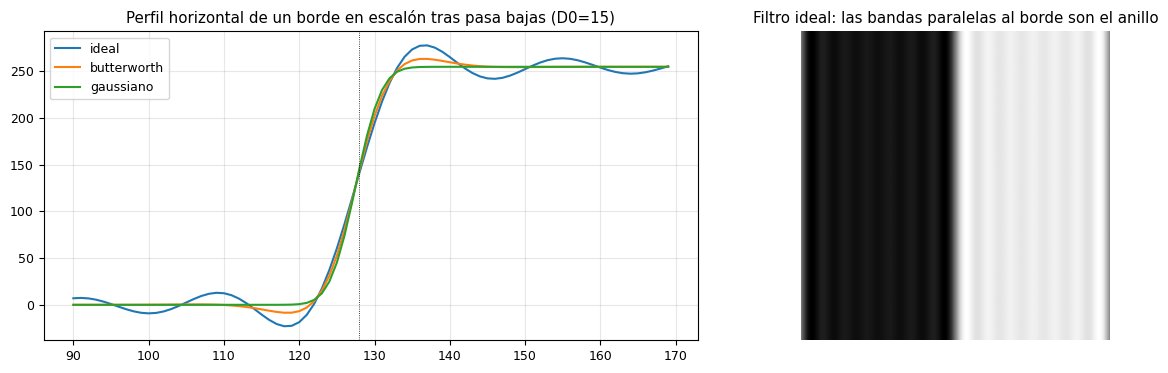

In [18]:
fig, ejes = plt.subplots(2, 4, figsize=(17, 8.4))
ejes[0, 0].imshow(rx, cmap="gray", vmin=0, vmax=255); ejes[0, 0].set_title("Original (referencia)")
ejes[0, 1].imshow(ruidosa, cmap="gray", vmin=0, vmax=255); ejes[0, 1].set_title("Con ruido gaussiano σ=25")
ejes[0, 2].imshow(espectro(rx), cmap="gray"); ejes[0, 2].set_title("Espectro de la original (log)")
ejes[0, 3].imshow(espectro(ruidosa), cmap="gray"); ejes[0, 3].set_title("Espectro con ruido: se \"llena\" de energía en alta frecuencia")
for a, t in zip(ejes[1, :3], tipos):
    D = mejor[t]; p, s_, im = tabla[(t, D)]
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(f"{t}, D0={D}: {p:.2f} dB")
# perfil radial del espectro: cuánta energía queda por debajo de cada frecuencia
Dm = malla_distancia(rx.shape).astype(int)
def perfil(img):
    P = np.abs(np.fft.fftshift(np.fft.fft2(img))) ** 2
    return np.bincount(Dm.ravel(), P.ravel()) / np.bincount(Dm.ravel())
for nombre, im in (("original", rx), ("con ruido", ruidosa)): ejes[1, 3].semilogy(perfil(im)[:200], label=nombre)
ejes[1, 3].set_xlabel("frecuencia radial D"); ejes[1, 3].set_title("Potencia espectral por frecuencia"); ejes[1, 3].legend(); ejes[1, 3].grid(alpha=.3)
for a in ejes.ravel()[:7]: a.axis("off")
plt.tight_layout(); plt.show()

# Efecto de anillo (ringing): un borde en escalón limpio filtrado con D0=15; se mide el sobreimpulso y el subimpulso
paso = np.zeros((256, 256)); paso[:, 128:] = 255
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
print(f"{'filtro':13s} {'sobreimpulso':>13s} {'subimpulso':>11s}   (respecto al salto de 255 niveles)")
for t in tipos:
    fila = filtrar(paso, pasa_bajas(paso.shape, 15, t))[128]
    print(f"{t:13s} {(fila.max() - 255) / 255 * 100:12.1f}% {(0 - fila.min()) / 255 * 100:10.1f}%")
    ax[0].plot(np.arange(90, 170), fila[90:170], label=t)
ax[0].axvline(128, color="k", lw=.6, ls=":"); ax[0].set_title("Perfil horizontal de un borde en escalón tras pasa bajas (D0=15)"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].imshow(np.clip(filtrar(paso, pasa_bajas(paso.shape, 15, "ideal")), -60, 315), cmap="gray"); ax[1].set_title("Filtro ideal: las bandas paralelas al borde son el anillo"); ax[1].axis("off")
plt.tight_layout(); plt.show()


**Resultados y discusión.**
- **Reducción de ruido.** La radiografía con ruido tiene 20.26 dB de PSNR y 0.160 de SSIM. El mejor resultado por PSNR se obtiene con el Butterworth y D0=50 (31.61 dB, +11.4 dB), seguido del gaussiano (31.52 dB) y del ideal (30.68 dB). El espectro de potencia lo explica: el ruido blanco añade una meseta de potencia constante en toda la banda de alta frecuencia, mientras que la potencia de la radiografía decae con la frecuencia; un corte en la zona donde ambas curvas se separan elimina el ruido conservando casi toda la energía de la imagen.
- **La frecuencia de corte es un compromiso.** Con D0=15 el filtrado borra detalle (27.5–28.7 dB) y con D0=120 deja pasar casi todo el ruido (26.7–27.8 dB); el óptimo por PSNR está cerca de D0=50. Además, PSNR y SSIM no coinciden: el SSIM, que mide la estructura, alcanza su máximo con D0=30 (0.87 con Butterworth y gaussiano), un suavizado más fuerte que el que prefiere el PSNR.
- **Efecto de anillo (*ringing*).** En un borde en escalón filtrado con D0=15 el filtro ideal produce un sobreimpulso y un subimpulso de 9.0 % del salto; el Butterworth (n=2), de 3.3 %; y el gaussiano, de 0 %. En la radiografía esto se traduce en que, con el mismo D0, el ideal siempre queda por debajo de los otros dos (por ejemplo, 30.04 dB frente a 30.85 y 31.15 dB con D0=30). El filtro ideal es útil para entender el concepto, pero no para aplicaciones reales.
- El precio de cualquier pasa bajas es suavizar los bordes y las estructuras finas (vasos, costillas), por lo que en imagen médica se combina con un criterio de calidad diagnóstica y no solo con una métrica.


<a id="b"></a>
## Ejercicio b) Filtro pasa altas: recuperar nitidez con énfasis de alta frecuencia

**Investigación.** Un filtro pasa altas conserva los detalles finos y bordes y elimina el fondo suave (el término de frecuencia cero, que es el brillo medio). Solo, produce una imagen de bordes casi negra; por eso, para **mejorar la nitidez** se usa el *filtrado de énfasis de alta frecuencia*:
$H_{hfe}(u,v) = a + b\,H_{HP}(u,v)$, con $a \ge 0$ y $b > a$ (Gonzalez & Woods, 2018, cap. 4). Con $a=1$ y $b>0$ equivale a la máscara de enfoque: $g = f + b\,\text{HP}(f)$. Se aplica en radiografías, imágenes satelitales y microscopía para realzar bordes y en preprocesamiento antes de detectar contornos.

**Demo.** La radiografía se desenfoca con un gaussiano (σ = 2 px) para simular una toma borrosa, y se intenta recuperar con cada filtro pasa altas (D0 = 30, a = 1, b = 1.5). Como se conoce la imagen nítida original, se mide PSNR, SSIM y un índice de nitidez (varianza del Laplaciano).

In [19]:
def nitidez(g): return float(cv2.Laplacian(g.astype(np.float32), cv2.CV_32F).var())

borrosa = cv2.GaussianBlur(rx, (0, 0), 2.0)
print(f"{'imagen':30s} {'PSNR':>7s} {'SSIM':>7s} {'nitidez':>9s}")
print(f"{'nítida (referencia)':30s} {'':>7s} {'':>7s} {nitidez(rx):9.1f}")
print(f"{'borrosa (σ=2)':30s} {psnr(rx, borrosa, data_range=255):7.2f} {ssim(rx, borrosa, data_range=255):7.3f} {nitidez(borrosa):9.1f}")
res = {}
for t in tipos:
    for D0 in (20, 30, 50):
        salida = np.clip(borrosa + 1.5 * filtrar(borrosa, pasa_altas(rx.shape, D0, t)), 0, 255)
        res[(t, D0)] = salida
        print(f"{t + ', D0=' + str(D0):30s} {psnr(rx, salida, data_range=255):7.2f} {ssim(rx, salida, data_range=255):7.3f} {nitidez(salida):9.1f}")

imagen                            PSNR    SSIM   nitidez
nítida (referencia)                                 48.7
borrosa (σ=2)                    37.21   0.938       0.6
ideal, D0=20                     29.31   0.881       5.2
ideal, D0=30                     31.37   0.904       7.6
ideal, D0=50                     33.14   0.916      17.9
butterworth, D0=20               30.54   0.928       4.9


butterworth, D0=30               32.59   0.948       7.1
butterworth, D0=50               34.25   0.950      15.7
gaussiano, D0=20                 31.14   0.940       5.3
gaussiano, D0=30                 33.06   0.953       8.2
gaussiano, D0=50                 34.65   0.952      18.8


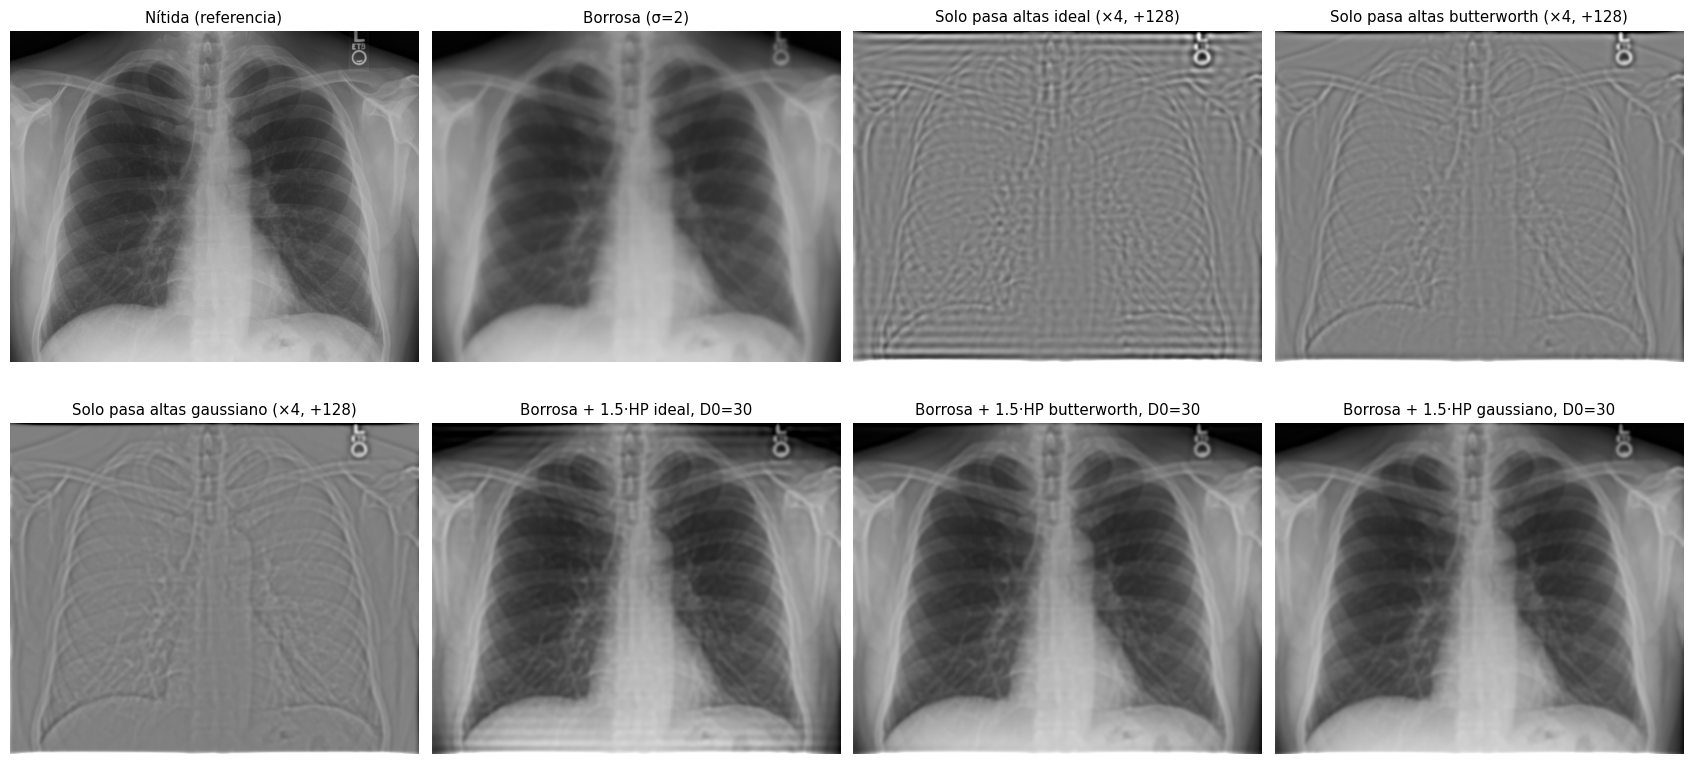

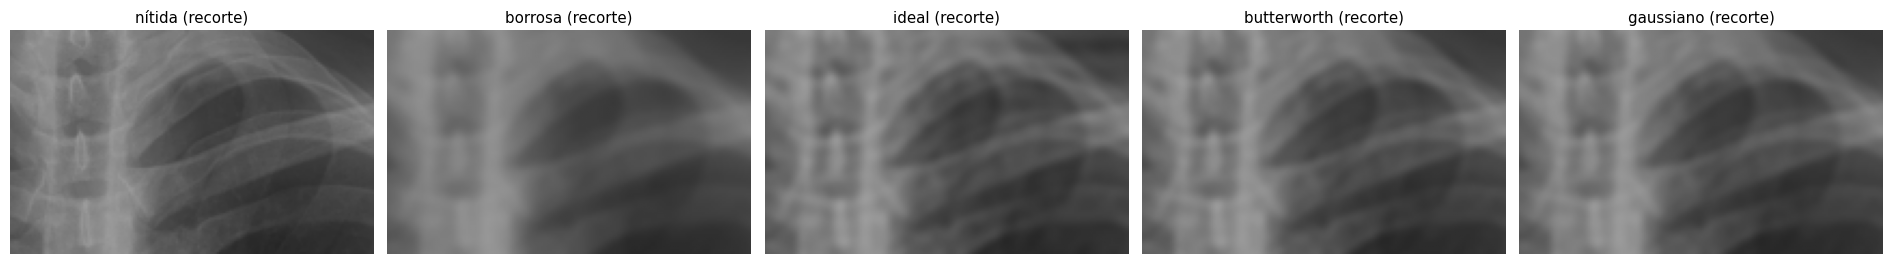

In [20]:
fig, ejes = plt.subplots(2, 4, figsize=(17, 8.4))
ejes[0, 0].imshow(rx, cmap="gray", vmin=0, vmax=255); ejes[0, 0].set_title("Nítida (referencia)")
ejes[0, 1].imshow(borrosa, cmap="gray", vmin=0, vmax=255); ejes[0, 1].set_title("Borrosa (σ=2)")
for a, t in zip(ejes.ravel()[2:5], tipos):
    solo = filtrar(borrosa, pasa_altas(rx.shape, 30, t)); a.imshow(np.clip(solo * 4 + 128, 0, 255), cmap="gray", vmin=0, vmax=255); a.set_title(f"Solo pasa altas {t} (×4, +128)")
for a, t in zip(ejes.ravel()[5:8], tipos):
    a.imshow(res[(t, 30)], cmap="gray", vmin=0, vmax=255); a.set_title(f"Borrosa + 1.5·HP {t}, D0=30")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

h, w = rx.shape; y0, y1, x0, x1 = int(h * .05), int(h * .30), int(w * .42), int(w * .75)
fig, ejes = plt.subplots(1, 5, figsize=(19, 3.4))
for a, (t, im) in zip(ejes, (("nítida", rx), ("borrosa", borrosa), ("ideal", res[("ideal", 30)]), ("butterworth", res[("butterworth", 30)]), ("gaussiano", res[("gaussiano", 30)]))):
    a.imshow(im[y0:y1, x0:x1], cmap="gray", vmin=0, vmax=255); a.set_title(t + " (recorte)"); a.axis("off")
plt.tight_layout(); plt.show()


**Resultados y discusión.**
- La imagen desenfocada tiene 37.21 dB de PSNR, 0.938 de SSIM y un índice de nitidez de 0.6, frente a 48.7 de la imagen nítida. Todas las variantes con énfasis de alta frecuencia **aumentan la nitidez** (entre 4.9 y 18.8), pero **ninguna alcanza el valor de la imagen original**.
- El **PSNR baja en todos los casos** (29.3 a 34.7 dB frente a 37.2 dB): sumar componentes de alta frecuencia no reconstruye exactamente las que el desenfoque eliminó, y amplifica el ruido de cuantización y produce sobreimpulsos. El **SSIM mejora** con Butterworth y gaussiano cuando D0 ≥ 30 (0.948–0.953 frente a 0.938), pero **empeora con el filtro ideal** (0.881–0.916) por el anillo. Una imagen más «nítida» no es necesariamente más parecida a la original.
- Con D0 mayores (50) los resultados son mejores que con D0 pequeños (20): un corte bajo aplica el realce a una banda demasiado ancha, incluyendo frecuencias medias donde hay más ruido que detalle. El **gaussiano** es el mejor (34.65 dB y 0.952 con D0=50) y el ideal el peor, en coherencia con el ejercicio anterior.
- El filtro pasa altas por sí solo (figura de bordes) devuelve una imagen casi negra con solo los bordes: el brillo medio desaparece. Para que sirva como realce hay que sumarlo a la imagen original, que es lo que hace el énfasis de alta frecuencia.
- Si la causa del desenfoque se conoce (aquí, un gaussiano de σ=2), la técnica adecuada es la **deconvolución** (filtro inverso o de Wiener), que divide por la respuesta en frecuencia del desenfoque en lugar de sumar un filtro pasa altas genérico.


<a id="conclusion"></a>
## Conclusión


- En el dominio de Fourier, filtrar es **multiplicar** el espectro por una función de transferencia; la misma operación en el dominio espacial exige una convolución. El costo se reduce con la FFT y permite diseñar el filtro pensando en frecuencias.
- **Pasa bajas = quitar ruido y detalle.** Con ruido gaussiano de σ=25, el mejor filtro (Butterworth, D0=50) subió el PSNR de 20.26 a 31.61 dB. La frecuencia de corte es un compromiso entre ruido residual (corte alto) y desenfoque (corte bajo).
- **Pasa altas = realzar detalle.** El énfasis de alta frecuencia aumentó la nitidez de una imagen borrosa (de 0.6 a 4.9–18.8), pero redujo el PSNR y solo mejoró el SSIM con los filtros suaves; para desenfoques conocidos conviene la deconvolución.
- **Ideal, Butterworth y gaussiano.** El filtro ideal produce anillo (9.0 % de sobreimpulso en un escalón), el Butterworth de orden 2 lo reduce a 3.3 % y el gaussiano lo elimina, y en todas las pruebas el ideal fue el peor. La elección práctica suele ser el gaussiano o el Butterworth.
- **Métricas.** PSNR y SSIM pueden preferir parámetros distintos; conviene usar ambas y mirar la imagen.
- Limitaciones: una sola radiografía y ruido sintético gaussiano; el ruido real de un equipo es más complejo (dependiente de la señal, correlacionado). Además, se comprobó que la versión vectorizada del filtro ideal coincide exactamente con la del notebook base (diferencia máxima 0), y se generó un tablero `left01.jpg` propio porque el original no venía con la actividad.


## Referencias

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. (Cap. 4: Filtering in the frequency domain.)
- Cooley, J. W., & Tukey, J. W. (1965). An algorithm for the machine calculation of complex Fourier series. *Mathematics of Computation, 19*(90), 297–301. https://doi.org/10.1090/S0025-5718-1965-0178586-1
- Butterworth, S. (1930). On the theory of filter amplifiers. *Experimental Wireless and the Wireless Engineer, 7*, 536–541.
- Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). Image quality assessment: From error visibility to structural similarity. *IEEE Transactions on Image Processing, 13*(4), 600–612. https://doi.org/10.1109/TIP.2003.819861
- Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. *Nature, 585*, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons: Rivera y Stillwaterising, CC0). El tablero `left01.jpg` es generado por código.